In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
from data_loader import load_weekly_data, load_supplementary
input_data, output_data = load_weekly_data()

In [ ]:

# Clean tracking data
# Clean orientation and direction
input_data["o_clean"] = (-(input_data["o"] - 90)) % 360
input_data["dir_clean"] = (-(input_data["dir"] - 90)) % 360
# Set x on same scale
input_data["x_clean"] = np.where(
      input_data["play_direction"] == "left",
      120 - input_data["x"],
      input_data[
          "x"
      ], 
  )
# y, s, a alreday clean
input_data["y_clean"] = input_data["y"]
input_data["s_clean"] = input_data["s"]
input_data["a_clean"] = input_data["a"]
# Clean orientation based on play direction
input_data["o_clean"] = np.where(
    input_data["play_direction"] == "left", 180 - input_data["o_clean"], input_data["o_clean"]
)
# Clean orientation, direction, vx, and vy
input_data["o_clean"] = (input_data["o_clean"] + 360) % 360 
input_data["dir_clean"] = (input_data["dir_clean"] + 360) % 360
input_data["dir_radians"] = np.radians(input_data["dir_clean"])
input_data["v_x"] = input_data["s_clean"] * np.cos(input_data["dir_radians"])
input_data["v_y"] = input_data["s_clean"] * np.sin(input_data["dir_radians"])

# Add in previous location
input_data["prev_x"] = input_data["x_clean"].shift(1)
input_data["prev_y"] = input_data["y_clean"].shift(1)
# Remove NAs
input_data = input_data.dropna()

In [ ]:
# Previewing data for later preparation 

input_data.head()

input_data.shape

(4880578, 35)

In [8]:
input_data["player_side"].value_counts()

player_side
Defense    2662656
Offense    2217922
Name: count, dtype: int64

In [7]:
input_data.columns

Index(['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id',
       'play_direction', 'absolute_yardline_number', 'player_name',
       'player_height', 'player_weight', 'player_birth_date',
       'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a',
       'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'wk',
       'o_clean', 'dir_clean', 'x_clean', 'y_clean', 's_clean', 'a_clean',
       'dir_radians', 'v_x', 'v_y'],
      dtype='object')

## PCA

In [ ]:
# interested in offense only data
offense = input_data[input_data['player_side'] == 'Offense'].copy()
# get pre snap data only
pre_snap = offense.loc[offense.groupby(['game_id', 'play_id', 'nfl_id'])['frame_id'].idxmin()]

feature_columns = ["x_clean", "y_clean", "s_clean", "a_clean", "o_clean", "dir_clean", "v_x", "v_y"]

X = pre_snap[feature_columns].values # Subset for predictors of interest above 


In [9]:
offense.head()

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,wk,o_clean,dir_clean,x_clean,y_clean,s_clean,a_clean,dir_radians,v_x,v_y
130,2023090700,101,False,53541,1,right,42,Amon-Ra St. Brown,6-1,195,...,1,15.28,359.30,40.61,19.12,0.00,0.00,6.270968,0.000000,-0.000000
131,2023090700,101,False,53541,2,right,42,Amon-Ra St. Brown,6-1,195,...,1,14.39,1.66,40.61,19.12,0.00,0.00,0.028972,0.000000,0.000000
132,2023090700,101,False,53541,3,right,42,Amon-Ra St. Brown,6-1,195,...,1,13.35,14.58,40.62,19.12,0.02,0.38,0.254469,0.019356,0.005035
133,2023090700,101,False,53541,4,right,42,Amon-Ra St. Brown,6-1,195,...,1,13.35,10.32,40.63,19.12,0.16,1.38,0.180118,0.157412,0.028663
134,2023090700,101,False,53541,5,right,42,Amon-Ra St. Brown,6-1,195,...,1,9.99,0.65,40.67,19.12,0.48,3.08,0.011345,0.479969,0.005445


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
pipe = Pipeline([ # pipeline definition, with only PCA to start of 
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

pipe.fit(X) # fit the pipeline to data

pca_model = pipe.named_steps["pca"]
explained_var = pca_model.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)
n_components = len(explained_var)

ev_df = pd.DataFrame({ # PCA metrics 
    "PC": np.arange(1, n_components + 1),
    "ExplainedVariance": explained_var,
    "CumulativeVariance": cum_explained_var
})


fig_scree = px.line( # plotly scree plot HERE
    ev_df, x="PC", y="ExplainedVariance",
    markers=True,
    title="Scree Plot: Proportion of Variance Explained"
)
fig_scree.show()


In [16]:
ev_df

,PC,ExplainedVariance,CumulativeVariance
0,1,0.179744,0.179744
1,2,0.152100,0.331844
2,3,0.136903,0.468748
3,4,0.125003,0.593751
4,5,0.124180,0.717931
5,6,0.112980,0.830911
6,7,0.098098,0.929008
7,8,0.070992,1.000000


In [ ]:
X_pca_scores = pipe.transform(X)
pc_cols = [f"PC{i}" for i in range(1, n_components + 1)] 
# check transformed data and associated PC columns
scores_df = pd.DataFrame(X_pca_scores, columns=pc_cols)
scores_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-0.639689,0.321379,1.315305,-0.761287,0.239399,-1.091044,-0.393228,0.188718
1,-0.537587,-0.038197,-2.096716,-0.547900,-0.157057,0.163722,0.489521,0.239833
2,-0.501493,-0.484712,-1.746707,-0.570387,-0.201352,0.912695,0.638209,0.254577
3,-0.482079,-1.252607,0.615647,-0.608022,-0.068982,0.817584,0.827926,0.262615
4,-0.541234,-0.600849,0.569481,-1.219464,0.119698,-0.368698,0.544744,0.234175
...,...,...,...,...,...,...,...,...
78852,-0.609380,0.254004,0.588917,0.659218,-0.126486,1.452638,-0.916289,0.201484
78853,4.790498,-3.028344,-0.897330,0.531864,0.375026,-0.997550,-1.836367,0.700485
78854,-0.553070,-0.610331,0.928855,0.439477,-0.074161,-0.123659,0.320022,0.235917
78855,-0.613770,-0.003279,1.159009,0.451366,0.034868,-0.909184,-0.129820,0.208114


In [ ]:
# transforming data to check for optimal amount of clusters
silhouette = {}
inertias = {}

X_pca = pipe.transform(X) 

for k in range(2, 15): # check for optimal k-values
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_pca)

    silhouette[k] = silhouette_score(X_pca, kmeans.labels_)
    inertias[k] = kmeans.inertia_

In [ ]:
# Identify best k-value here based on silhouette score
optimal_k = max(silhouette, key = silhouette.get)

print("Best k based on Silhouette Score:", optimal_k)

Best k based on Silhouette Score: 4


# add kmeans in here, choosing k = 8, to try to get variability in the groups, before choosing the optimal number of clusters

In [20]:
# Redefining the FULL pipeline here with K-Means included

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),  
    ('kmeans', KMeans(n_clusters=8, n_init=10, random_state=42)) # 3,4 clusters, probbaly better, but want more to see more variabiltiy in different types of plays
])

pipe.fit(X)

pca = pipe.named_steps['pca']

labels = pipe.named_steps['kmeans'].labels_
pre_snap["cluster"] = labels

# stats, checking cluster summaries 

print("PCA Components:", pca.n_components_)
print("Explained variance (ratio):", pca.explained_variance_ratio_)
print("Cluster counts:\n", pre_snap["cluster"].value_counts())

explained_var = pca.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)
n_components = len(explained_var)

df_pca = pd.DataFrame({
    "PC": np.arange(1, n_components + 1),
    "ExplainedVariance": explained_var,
    "CumulativeVariance": cum_explained_var
})

fig_scree = px.line(
    df_pca, x="PC", y="ExplainedVariance",
    markers=True,
    title="Scree Plot: Proportion of Variance Explained"
)
fig_scree.show()


PCA Components: 8
Explained variance (ratio): [0.17974374 0.1521004  0.1369034  0.12500335 0.12417982 0.11298002
 0.09809769 0.07099157]
Cluster counts:
 cluster
7    18315
1    17991
6    17553
0    16932
5     3134
3     2699
2     1142
4     1091
Name: count, dtype: int64


In [ ]:
X_pca_scores = pipe.transform(X)
pc_cols = [f"PC{i}" for i in range(1, n_components + 1)]

scores_df = pd.DataFrame(X_pca_scores, columns=pc_cols) # PCA influenec by cluster
scores_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,2.526388,3.042890,8.686848,4.337289,8.537013,4.170589,2.551280,0.916999
1,2.836706,1.561991,8.628385,4.353104,8.715889,4.323299,2.496230,3.246269
2,2.548612,1.915123,8.568152,4.335178,8.760650,4.305201,2.291680,3.350511
3,1.222797,3.003656,8.422716,4.232956,8.765602,4.142712,2.317131,2.385641
4,1.600632,2.772380,8.447433,4.128428,8.625145,4.015076,2.302506,1.468332
...,...,...,...,...,...,...,...,...
78852,2.640156,2.494817,8.710182,4.324244,8.505195,4.178887,1.393673,2.740367
78853,6.331478,6.547909,2.630496,5.548919,9.975604,5.870553,6.738273,6.598934
78854,0.911296,2.464571,8.407539,4.017577,8.543585,3.892857,2.180848,1.322772
78855,1.864233,2.608494,8.555379,4.155244,8.502038,4.005211,2.480189,0.828169


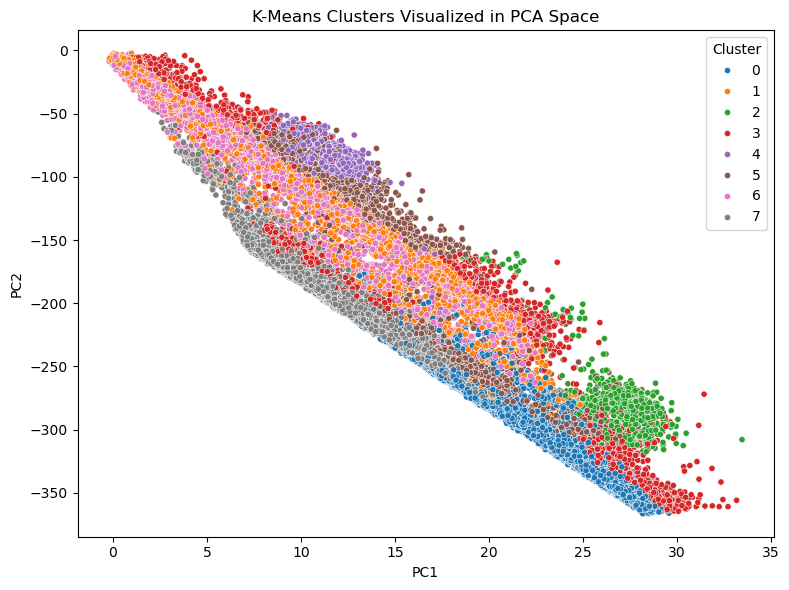

In [ ]:
plt.figure(figsize=(8, 6)) # visualizing K-Means clusters in PCA space
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels
)
plt.title("K-Means Clusters Visualized in PCA Space")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [11]:
cluster_summary = pre_snap.groupby("cluster")[feature_columns].mean()
cluster_summary

,x_clean,y_clean,s_clean,a_clean,o_clean,dir_clean,v_x,v_y
cluster,,,,,,,,
0,59.665639,28.735615,0.051120,0.202791,341.380896,273.490275,0.004669,-0.028023
1,63.156229,18.213343,0.049528,0.215758,24.734180,185.247564,-0.000016,-0.000453
2,53.931357,25.841471,6.012198,1.548678,274.317452,269.705377,-0.029775,-5.979709
3,53.976258,25.981445,0.771878,2.015695,181.840422,193.745587,0.410923,-0.048393
4,54.394592,27.798469,6.002887,1.545435,84.256022,90.170403,-0.021253,5.974146
5,53.498197,27.062387,0.745466,1.937562,183.127144,178.774234,-0.404385,0.026617
6,45.411322,33.124547,0.049561,0.193242,19.501352,174.747006,0.000113,0.003835
7,49.386815,27.497669,0.048304,0.209720,341.360644,91.628314,0.000751,0.022882


In [ ]:
# this section was used to calculate silhouette scores for different k-values, but incorrect because it used original data, not PCA transformed data

#from sklearn.metrics import silhouette_score

#sil_scores = []
#K_values_sil = list(range(2, 11))

#for k in K_values_sil:
#    pipe.set_params(kmeans__n_clusters=k)
#    pipe.fit(X)

#    labels = pipe["kmeans"].labels_

#    sil = silhouette_score(X, labels)

#   sil_scores.append(sil)

In [ ]:
#sil_scores

[0.5964978431860586,
 0.36080922265480636,
 0.05239384080925968,
 -0.0571828683878478,
 -0.0947305229725968,
 -0.11846299745992692,
 0.04473713307336704,
 -0.0375102166841824,
 -0.022241919935220615]

In [ ]:
# plotting silhouette scores for different k-values
lines = list(range(2, 11))
fig = px.line(
    x=lines,
    y=silhouette,
    markers= True,
    title="Silhouette Scores",
    labels={"x": "Number of K Clusters", "y": "Silhouette Scores"}
)

fig.show()

In [ ]:
# plotting elbow scores for different k-values

K_values = list(range(1, 11))
wcss = []

for k in K_values: # need within cluster sum of squares calculation HERE
    pipe.set_params(kmeans__n_clusters=k)
    pipe.fit(X)
    inertia = pipe["kmeans"].inertia_
    wcss.append(inertia)


fig = px.line( # plotting elbow plot for additional cluster evaluation
    x=K_values,
    y=wcss,
    markers=True,
    title="Elbow Plot",
    labels={"x": "Number of K Clusters", 
            "y": "WCSS"}
)

fig.show()

In [18]:
wcss

[630855.9999999994,
 551438.54948092,
 471368.64483789954,
 400163.93710699753,
 369232.42387105525,
 336780.1556552497,
 311925.66054958384,
 291508.43308068736,
 271488.7556982545,
 254983.26985821503]

# Chose K = 4 as the optimal number of clusters

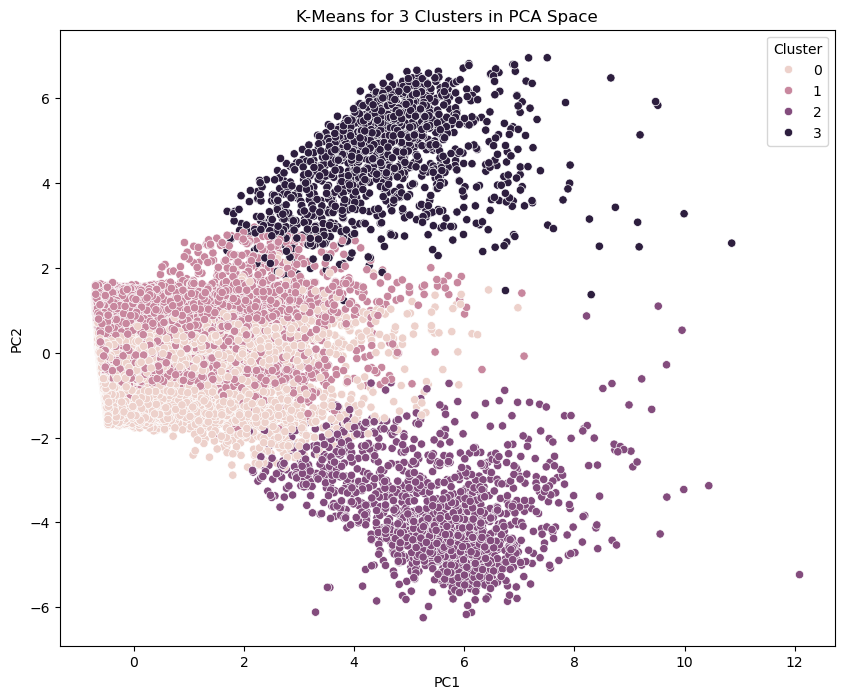

In [ ]:
pipe.set_params(kmeans__n_clusters=4) # setting K = 4
pipe.fit(X)

labels = pipe.named_steps['kmeans'].labels_
pre_snap["clusterk4"] = labels

X_pca = pipe.named_steps['pca'].transform(pipe.named_steps['scaler'].transform(X))

plt.figure(figsize=(10, 8)) # visualizing K-Means clusters in PCA space for K = 4
sns.scatterplot(x = X_pca[:, 0], y =X_pca[:, 1], hue=labels)
plt.title("K-Means for 4 Clusters in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

In [34]:
cluster4_summary = pre_snap.groupby("clusterk4")[feature_columns].mean()
print(cluster4_summary)

KeyError: 'clusterk4'

# next steps: t-sne, umap w/ hyperparameter tuning

# Sources

https://plotly.com/python/t-sne-and-umap-projections/ 

https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html 

https://umap-learn.readthedocs.io/en/latest/basic_usage.html 


In [23]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import umap.umap_ as umap

In [ ]:
# data prepraation
positions = pre_snap["player_position"].values # assign labels 
roles = pre_snap["player_role"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# take subset of data HERE because t-sne and umap are slow

n_sample = min(5000, len(X_scaled)) 
sample_idx = np.random.choice(len(X_scaled), n_sample, replace=False)
X_sample = X_scaled[sample_idx]
positions_sample = positions[sample_idx] # assign labels
roles_sample = roles[sample_idx] # assign labels

# initialize and fit t-SNE and UMAP

 # reducing TNSE to 2D, the parameter being tuned
    # Need to initialize t-SNE with PCA here 
    # lets t-SNE choose an appropriate learning rate

tsne = TSNE(
    n_components=2, 
    init="pca", 
    learning_rate="auto", 
    random_state=42
).fit_transform(X_sample)

umap_result = umap.UMAP(
    n_components=2, 
    random_state=42
).fit_transform(X_sample)

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [25]:
# establish data frame of results for both t-SNE and UMAP
tsne_df = pd.DataFrame({
    'tsne1': tsne[:, 0],
    'tsne2': tsne[:, 1],
    'position': positions_sample,
    'role': roles_sample
})

umap_df = pd.DataFrame({
    'umap1': umap_result[:, 0],
    'umap2': umap_result[:, 1],
    'position': positions_sample,
    'role': roles_sample
})

In [29]:
tsne_df.head()

,tsne1,tsne2,position,role
0,-27.729683,37.832767,WR,Targeted Receiver
1,19.529154,38.299217,WR,Other Route Runner
2,45.445110,22.259655,QB,Passer
3,19.310493,3.519994,WR,Other Route Runner
4,4.819965,22.953640,TE,Other Route Runner


In [30]:
umap_df.head()

,umap1,umap2,position,role
0,2.333175,9.391179,WR,Targeted Receiver
1,0.913659,10.350657,WR,Other Route Runner
2,-1.514589,10.832649,QB,Passer
3,5.095427,9.024852,WR,Other Route Runner
4,1.385595,7.958458,TE,Other Route Runner


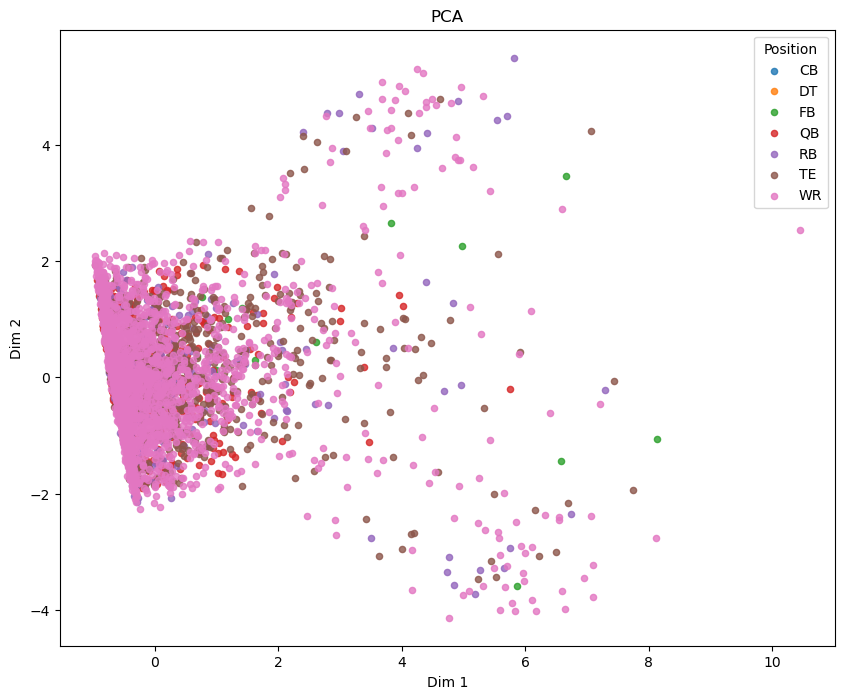

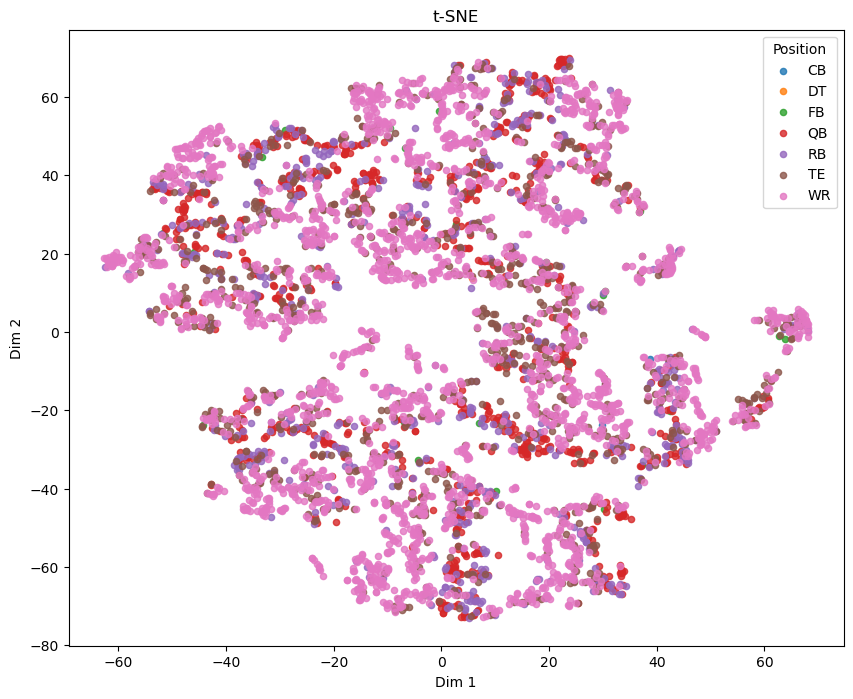

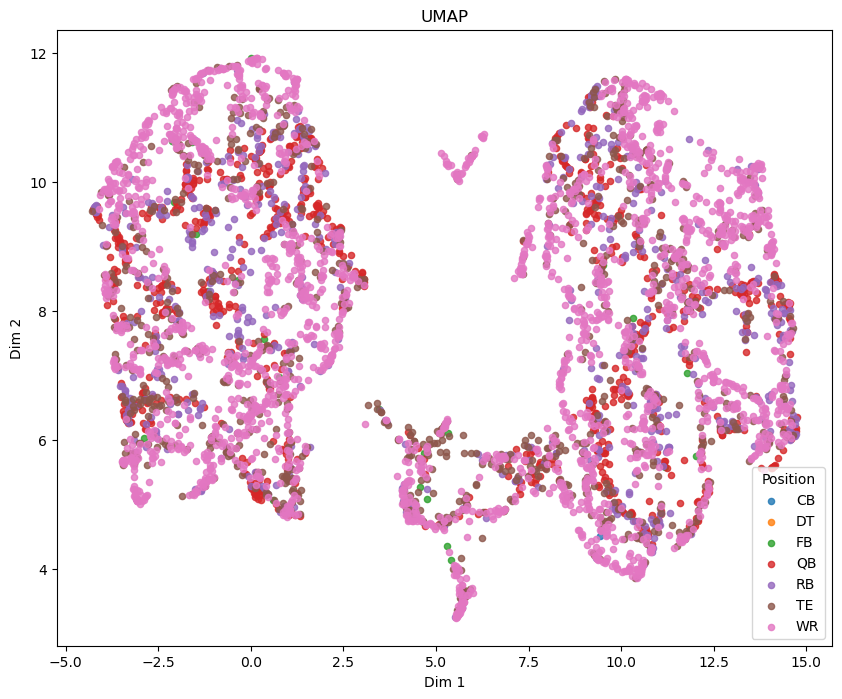

In [27]:
pca = PCA(n_components=2, random_state=42).fit_transform(X_sample)
# want to compare with t-SNE and UMAP, so will reduce to 2 PCs for consistency and interpretability

for emb, title in zip([pca, tsne, umap_result], ["PCA", "t-SNE", "UMAP"]): # looping through all models to plot them 
    plt.figure(figsize=(10, 8))
    uniq = np.unique(positions_sample) # grab unique positions 

    for pos in uniq:
        mask = positions_sample == pos
        plt.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=0.8, label = pos) # define clustering for each position 

    # plot formatting and such 
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")

    plt.title(title)

    plt.legend(title="Position")
    plt.show()

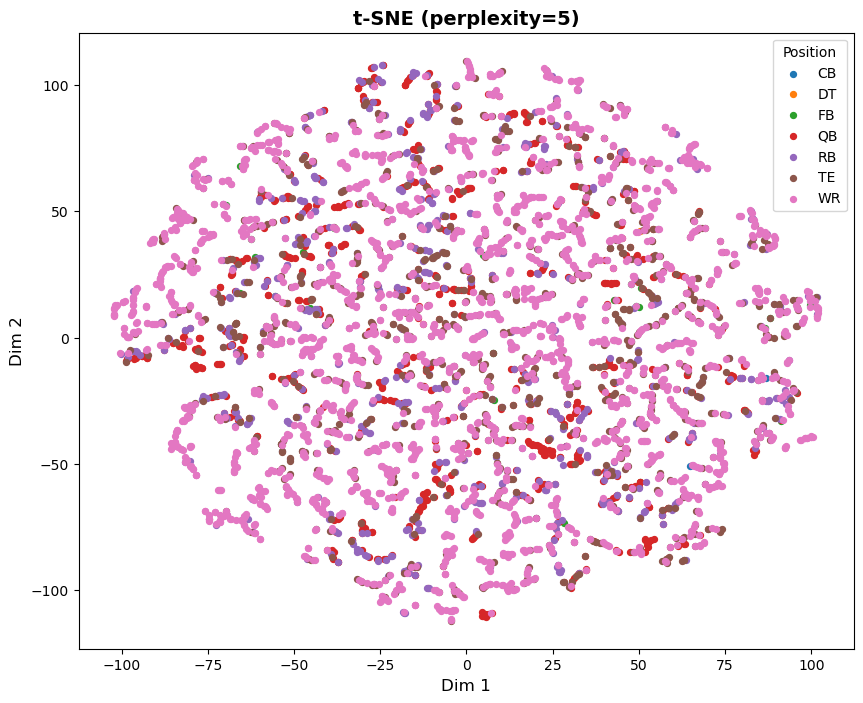

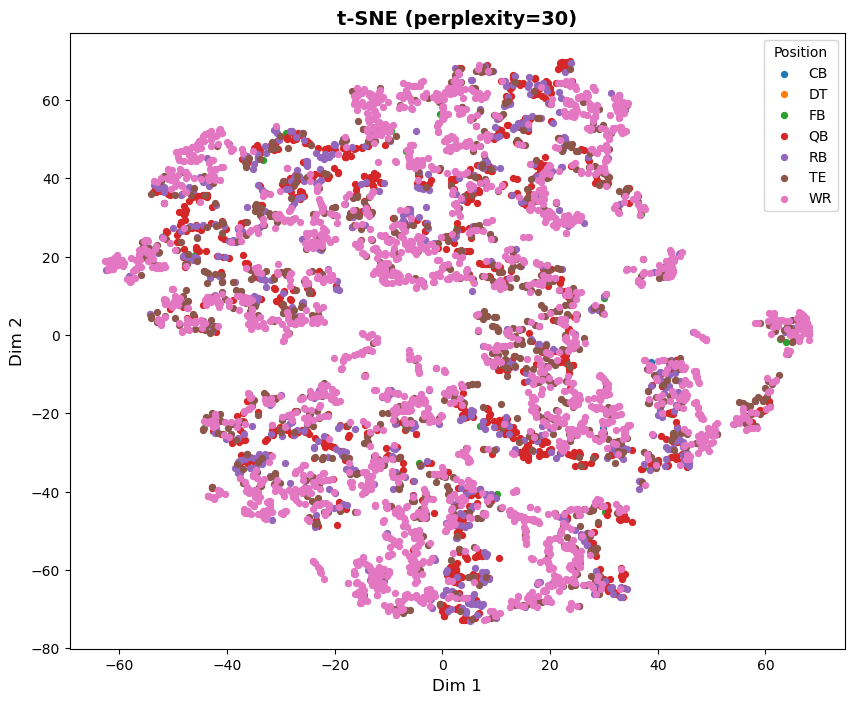

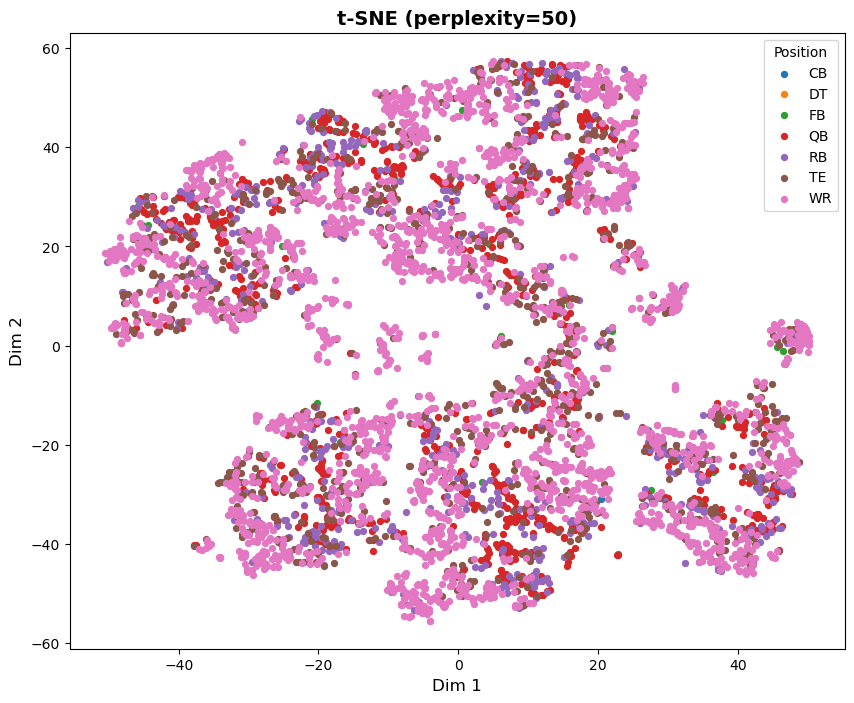

In [ ]:
# Hyperparameter Tuning 
# Tuning perplexity for t-SNE

def scatter_by_position(emb, title):
    plt.figure(figsize=(10, 8))
    for pos in np.unique(positions_sample):
        m = positions_sample == pos # position selection here
        plt.scatter(emb[m, 0], emb[m, 1], s=18, label=pos)
    
    # plot formatting
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Dim 1", fontsize=12)
    plt.ylabel("Dim 2", fontsize=12)
    plt.legend(title = "Position")

    plt.show()

# Parameter to tune for t-SNE: perplexity
for perp in [5, 30, 50]:
    emb = TSNE(n_components=2, perplexity=perp, init="pca", learning_rate="auto", random_state=42).fit_transform(X_sample)

    # reducing TNSE to 2D, the parameter being tuned
    # Need to initialize t-SNE with PCA here 
    # lets t-SNE choose an appropriate learning rate

    scatter_by_position(emb, f"t-SNE (perplexity={perp})")

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


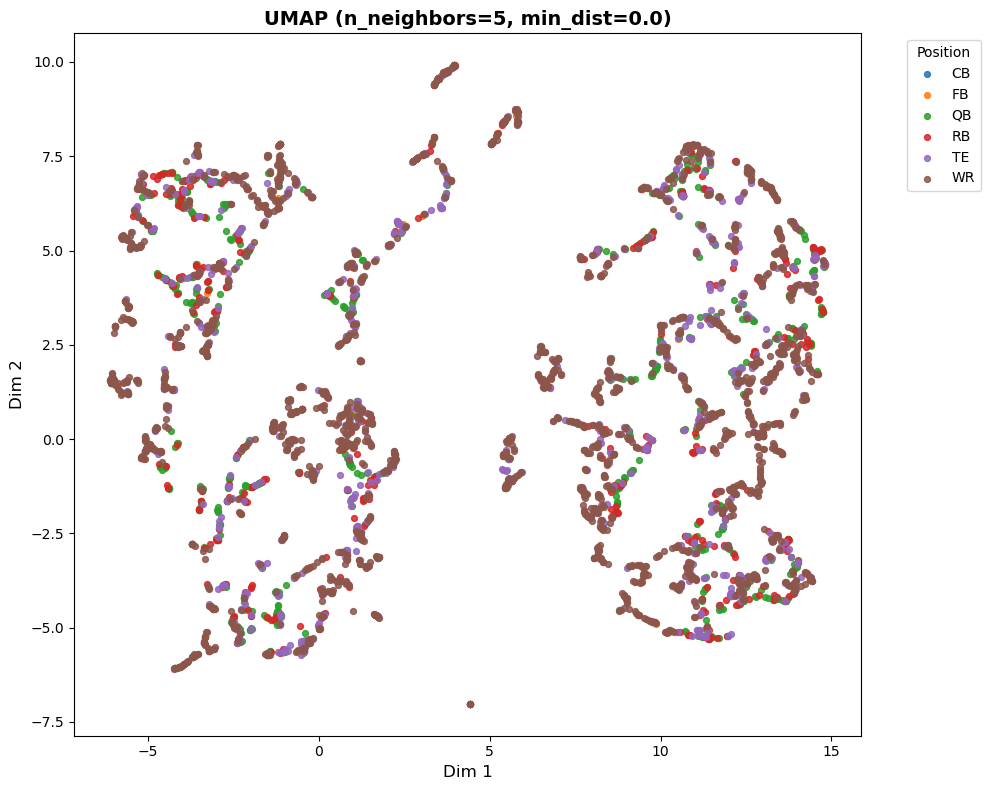

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


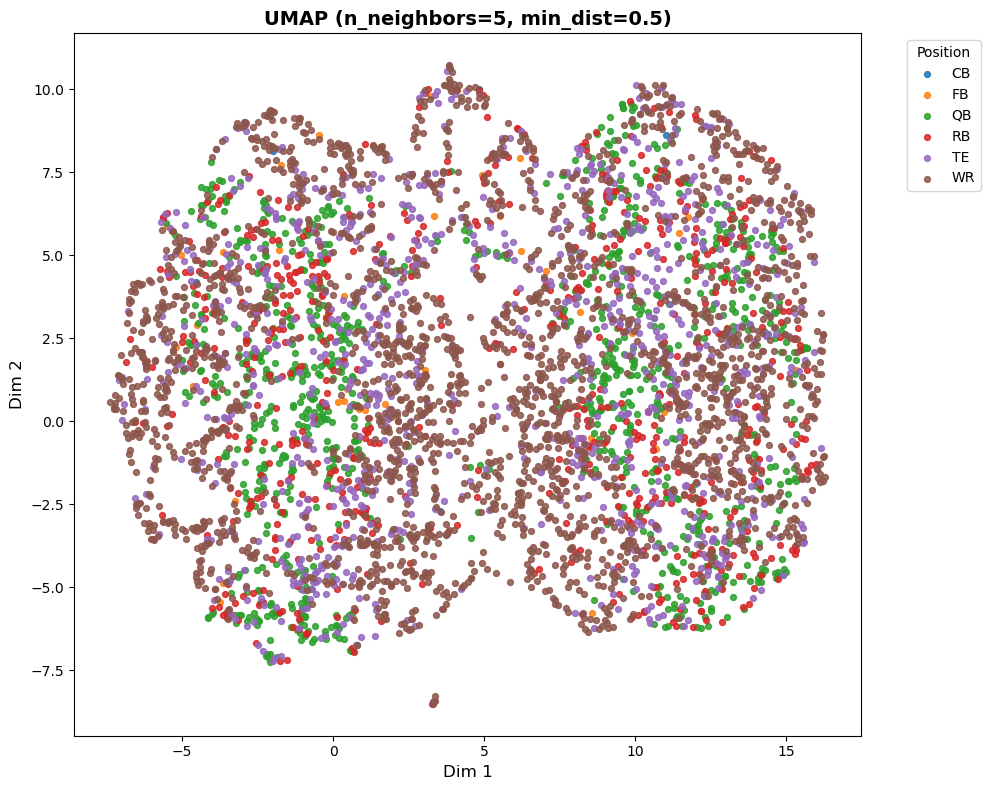

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


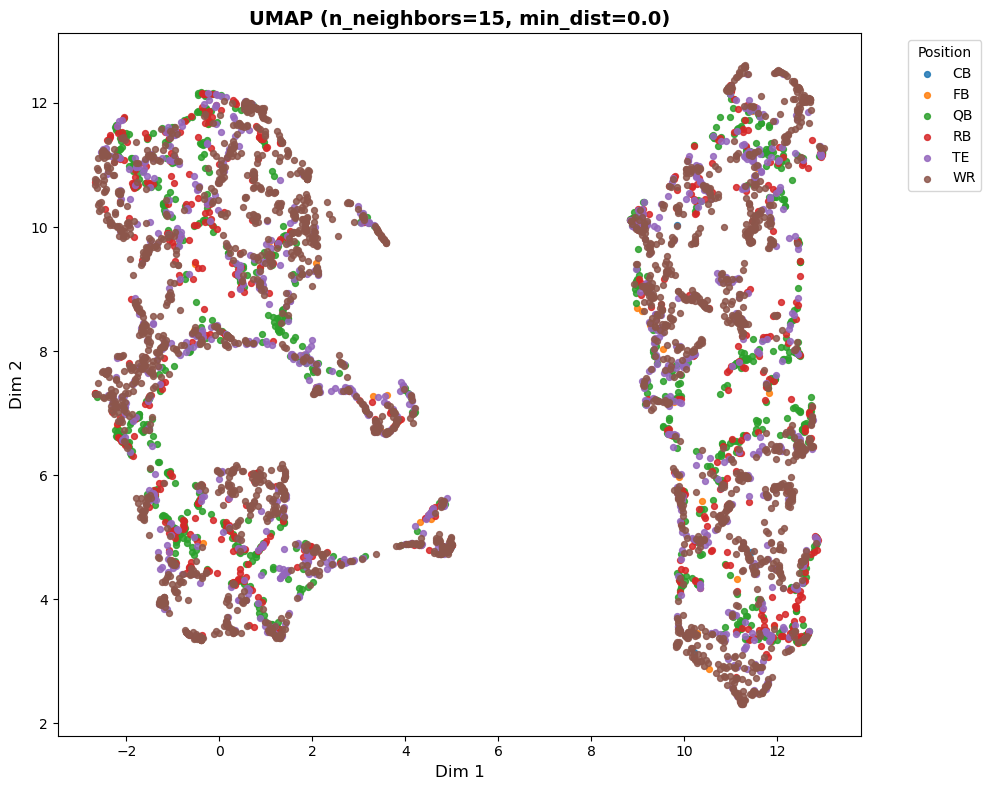

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


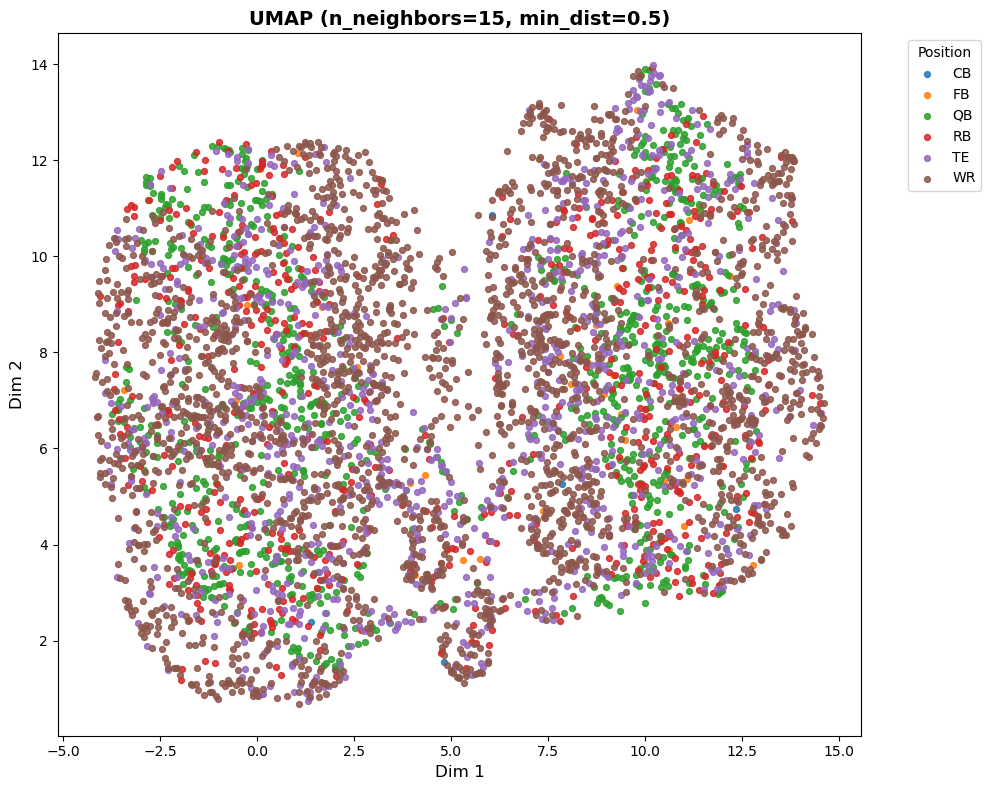

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


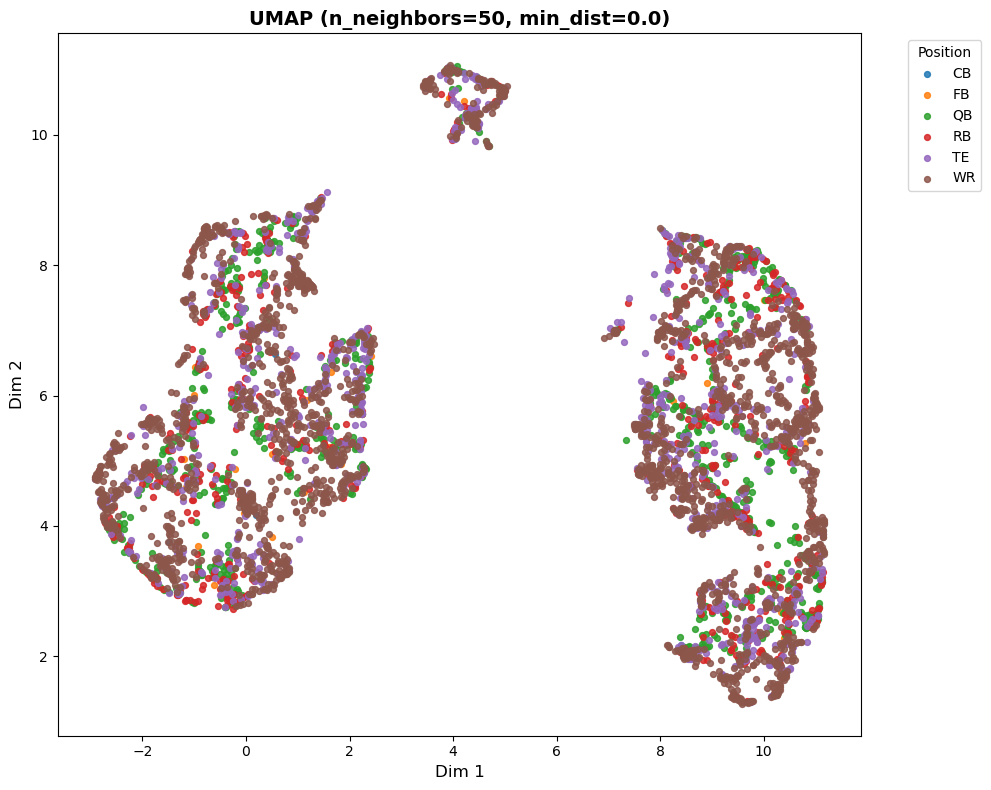

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


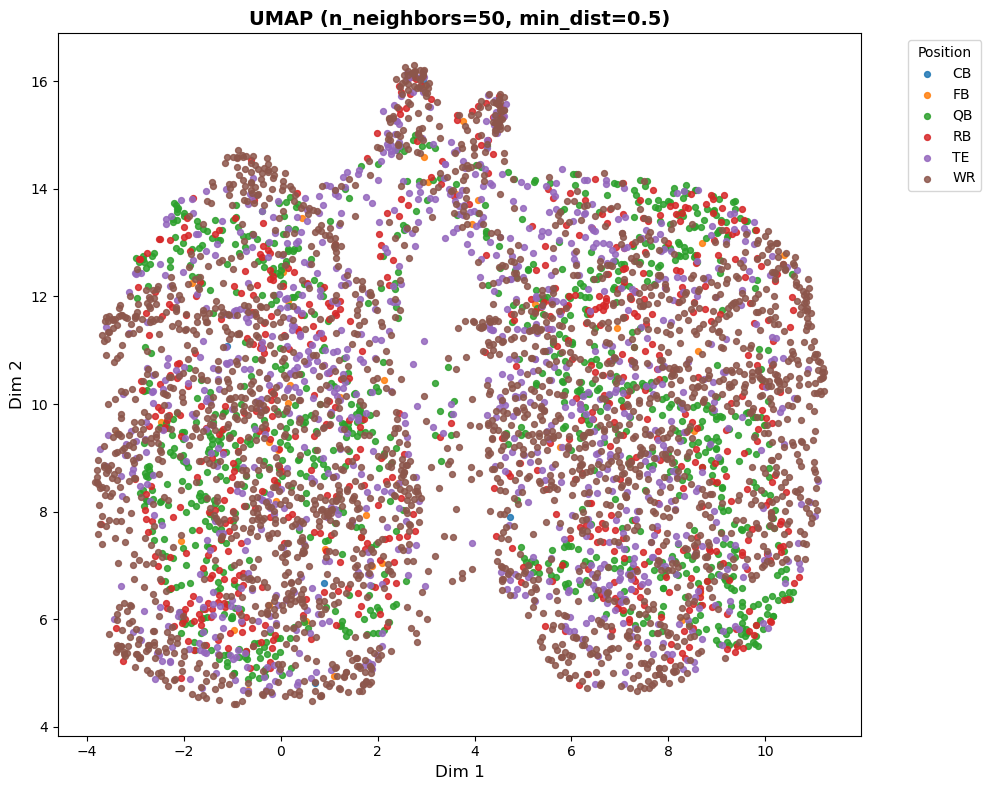

In [ ]:
# Hyperparamter Tuning: tuning n_neighbors & min_dist for umap

for nn in [5, 15, 50]: # testing various neighbor sizes
    for md in [0.0, 0.5]: # various tightness within the cluster itself 
        emb = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=md, random_state=42).fit_transform(X_sample)
        scatter_by_position(emb, f"UMAP (n_neighbors={nn}, min_dist={md})")

# PCR

In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression

In [ ]:
features = ['prev_x', 'prev_y', 'o_clean', 'dir_radians', 's_clean', 'a_clean', 'v_x', 'v_y']
X = offense[features].values
y = offense['x_clean'].values

X_train, X_test, y_train, y_test = train_test_split( # Standard train-test split
    X, y, test_size=0.25, random_state=42
)

pcr_pipe = Pipeline([ # FULL PCR pipeline
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=4)),
    ("linreg", LinearRegression())
])

pcr_pipe.fit(X_train, y_train)# fitting the PCR model on the training data

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,4
,copy,True
,whiten,False
,svd_solver,'auto'


In [31]:
train_r2 = pcr_pipe.score(X_train, y_train)
test_r2  = pcr_pipe.score(X_test, y_test)


y_train_pred = pcr_pipe.predict(X_train)
y_test_pred  = pcr_pipe.predict(X_test)


In [32]:
train_rmse = np.sqrt(np.mean((y_train - y_train_pred)**2))
test_rmse  = np.sqrt(np.mean((y_test - y_test_pred)**2))

print(f"Using n_components = {4}")
print(f"Train R²  : {train_r2:.4f}")
print(f"Test  R²  : {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")

Using n_components = 4
Train R²  : 0.4269
Test  R²  : 0.4276
Train RMSE: 17.7690
Test  RMSE: 17.7668


In [33]:
pca_model = pcr_pipe.named_steps['pca']
print(f"\nExplained variance by 3 PCs: {pca_model.explained_variance_ratio_.sum():.4f}")
print(f"Single PC variance: {pca_model.explained_variance_ratio_}")


Explained variance by 3 PCs: 0.6261
Single PC variance: [0.2254855  0.14439107 0.13079704 0.12541229]
